In [9]:
%load_ext autoreload
%autoreload 2
import numpy as np
import analysis_code.get_data
import matplotlib.pyplot as plt
import analysis_code.population_activity as pop
import analysis_code.helper_functions as hf
import analysis_code.analysis as analysis
import analysis_code.plots as plots
import analysis_code.statistics_test as st
from IPython.display import display

DATA_ROOT = 'C:/Users/oles/Documents/Data/antje_ca1/data_sig'  
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]

animal_ids = st.animal_labels(datapaths)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


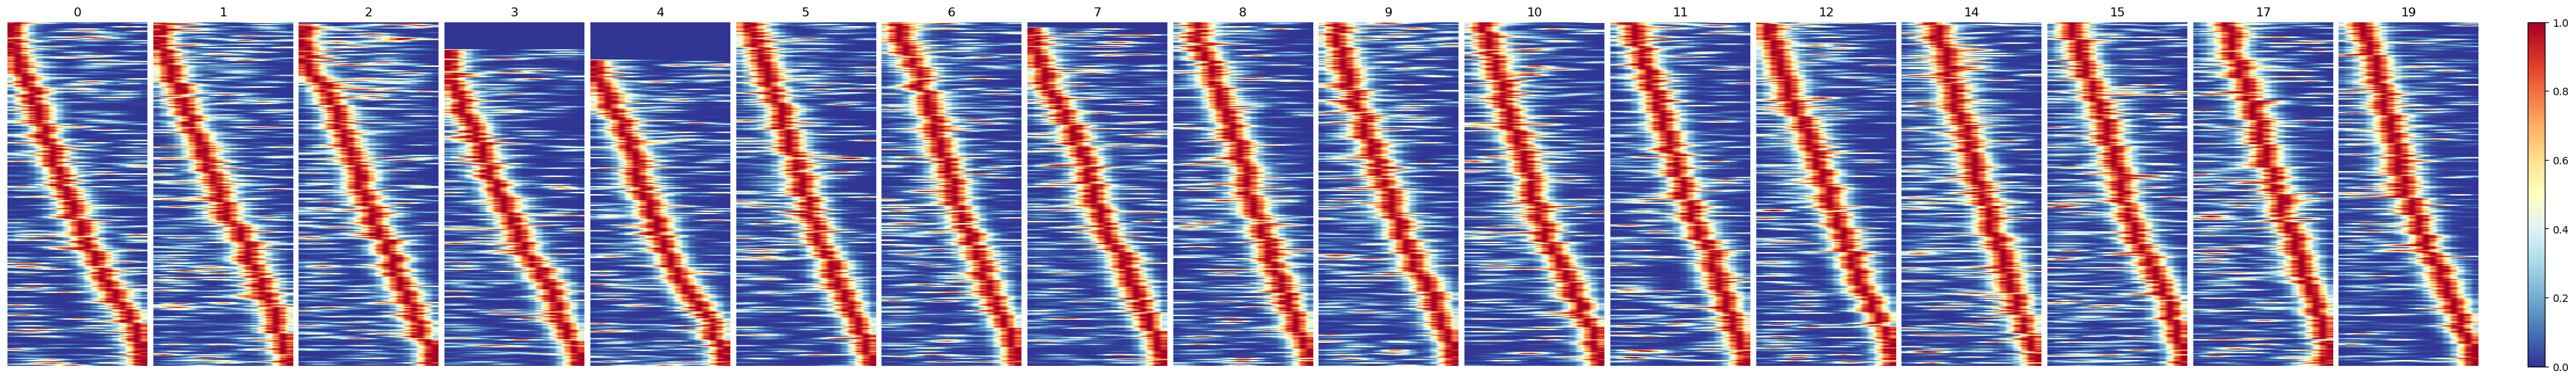

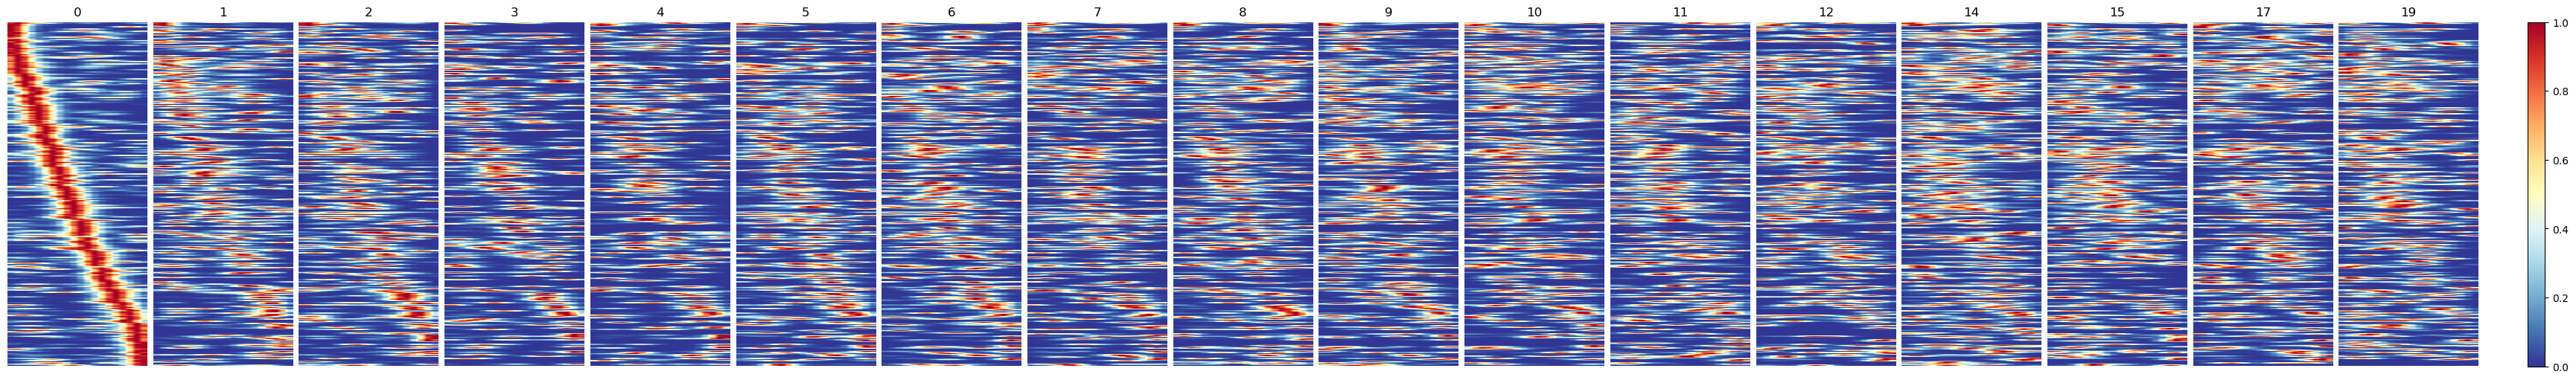

In [10]:
datapath = f'{DATA_ROOT}/170.h5'
maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
hist_sorts = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference='0', maps = maps, reference_type='own_reference', transients = False, hist='hist',  standardize='stand')
plots.plot_arrays(hist_sorts, ['0']+maps, remove_zero_rows=True)

hist_sorts = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference='0', maps = maps, reference_type='reference', transients = False, hist='hist',  standardize='stand')
plots.plot_arrays(hist_sorts, ['0']+maps,remove_zero_rows=True)

In [11]:
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]
results = []

for datapath in datapaths:
    scores_test, scores_new_list, predictions_test, predictions_new_list, y_test, y_new_list = analysis.decode_position(
        datapath, '0', maps, 'Context1', model='gnb', use_circular=False, align_sessions=False)
    
    results.append({
        'datapath': datapath,
        'scores_test': scores_test,
        'scores_new_list': scores_new_list,
        'predictions_test': predictions_test,
        'predictions_new_list': predictions_new_list,
        'y_test': y_test,
        'y_new_list': y_new_list
    })

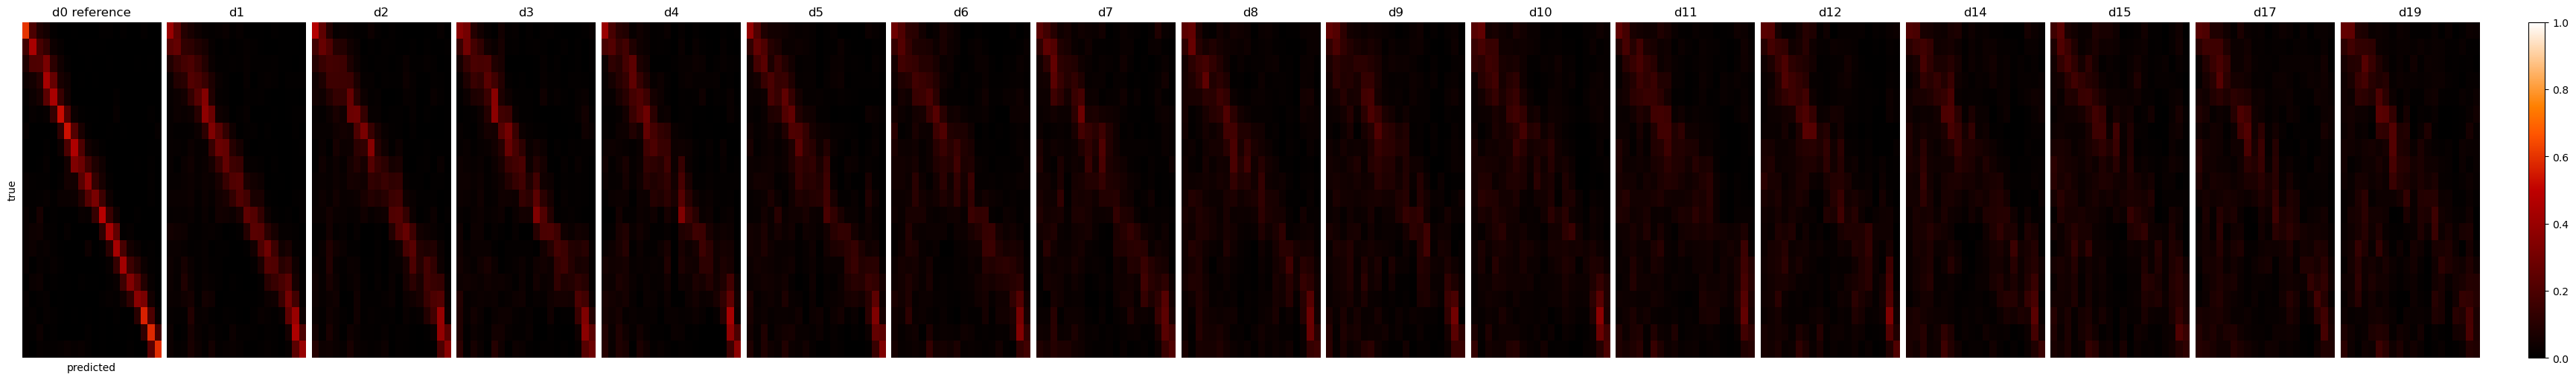

In [12]:
num_days = len(results[0]['scores_new_list'])
matrix_shape = results[0]['scores_new_list'][0]['cm_prob'].shape
sum_matrices = [np.zeros(matrix_shape) for _ in range(num_days)]
days = ['d0 reference', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10', 'd11', 'd12', 'd14', 'd15', 'd17', 'd19']
for a in range(len(results)):
    for day in range(num_days):
        sum_matrices[day] += results[a]['scores_new_list'][day]['cm_prob']

num_a = len(results)
avg_matrices = [sum_matrix / num_a for sum_matrix in sum_matrices]

avg_matrice_ref = np.mean([results[a]['scores_test']['cm_prob'] for a in range(len(results)) ],axis=0)
avg_matrices.insert(0, avg_matrice_ref)
plots.plot_arrays(avg_matrices, days, aspect=0.0, xlabel='predicted', ylabel='true', show_colorbar=True, smooth_sigma=False, remove_zero_rows=False, cmap='gist_heat', global_scale=True, scale_per_neuron=False)

In [13]:
results_shuff = []

for datapath in datapaths:
    scores_test, scores_new_list, predictions_test, predictions_new_list, y_test, y_new_list = analysis.decode_position(
        datapath, '0', maps, 'Context1', model='gnb', use_circular=False, align_sessions=False, shuffle=True)
    
    results_shuff.append({
        'datapath': datapath,
        'scores_test': scores_test,
        'scores_new_list': scores_new_list,
        'predictions_test': predictions_test,
        'predictions_new_list': predictions_new_list,
        'y_test': y_test,
        'y_new_list': y_new_list
    })

day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.3965,0.7030,0.7220,0.6479,0.7700,0.7814,0.8453,0.8902,0.8732,0.8822,0.9190,1.0437,0.9004,0.9839,1.0349,1.0450,1.0046
51004,0.3797,0.6194,0.9040,0.9419,1.0144,0.9765,1.0853,1.1872,1.2760,1.2388,1.3402,1.2007,1.3032,1.3023,1.2896,1.3295,1.2321
51007,0.2754,0.3314,0.4275,0.6309,0.5841,0.6207,0.7413,0.7001,0.7933,0.8230,0.9244,0.8762,0.8819,0.8293,0.8669,0.9408,0.8313
63,0.3854,0.8392,0.8844,0.9817,1.2617,1.1455,1.1338,1.2262,1.1178,1.2596,1.1090,1.1191,1.0255,1.2658,1.1940,1.0640,1.0703
64,0.1078,0.2903,0.3634,0.2561,0.2507,0.4315,0.5442,0.4764,0.6065,0.7714,0.6395,0.6844,0.5842,0.7277,0.7611,0.6775,0.5976
65,0.2025,0.4772,0.4316,0.5610,0.6109,0.6872,0.7626,0.8142,0.8650,0.8397,0.8325,0.8811,0.9138,0.9392,1.0808,1.1388,1.1364


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,1.1762,1.2785,1.2480,1.2135,1.2518,1.2324,1.2642,1.2666,1.2870,1.3382,1.1938,1.2038,1.2028,1.3202,1.2454,1.2356,1.3155
51004,1.2931,1.3185,1.3087,1.2930,1.2852,1.2368,1.2353,1.2899,1.4086,1.2980,1.3139,1.2768,1.3687,1.2914,1.2672,1.2619,1.3133
51007,1.2396,1.3029,1.3779,1.3534,1.2702,1.2544,1.2992,1.3355,1.3709,1.2591,1.2474,1.2576,1.3261,1.2592,1.3228,1.1923,1.2941
63,1.3189,1.3731,1.3807,1.3002,1.2627,1.3012,1.3503,1.3439,1.3426,1.3274,1.3744,1.4241,1.3758,1.2943,1.3869,1.4662,1.2774
64,1.3386,1.3793,1.3771,1.3500,1.3459,1.4313,1.4590,1.3761,1.4154,1.3685,1.3659,1.3425,1.3638,1.3694,1.3722,1.3519,1.3172
65,1.3269,1.3972,1.4463,1.4415,1.4653,1.4359,1.4061,1.3835,1.3550,1.3726,1.3358,1.3820,1.4202,1.5128,1.3318,1.3619,1.3421


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,2.094888,16,80,0.130930,29.866128,4.010545e-27,1.334263e-07,0.285789,0.227460
1,condition,12.287548,1,5,12.287548,24.705229,4.210185e-03,4.210185e-03,0.701230,1.000000
2,time * condition,1.944246,16,80,0.121515,18.312849,2.189110e-20,5.937006e-05,0.270803,0.170656


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d0,real,shuffle,t-test,-15.0541,2.3427e-05,0.0004,***,-6.1458,Cohen's d,0.2912,1.2822,-0.9910,0.1612,6,True,0.7650
1,d1,real,shuffle,t-test,-8.5955,0.0004,0.0060,**,-3.5091,Cohen's d,0.5434,1.3416,-0.7982,0.2275,6,True,0.4977
2,d2,real,shuffle,t-test,-6.2657,0.0015,0.0258,*,-2.5580,Cohen's d,0.6221,1.3565,-0.7343,0.2871,6,True,0.0615
3,d3,real,shuffle,t-test,-5.2830,0.0032,0.0550,,-2.1568,Cohen's d,0.6699,1.3252,-0.6553,0.3038,6,True,0.7123
4,d4,real,shuffle,t-test,-3.4786,0.0177,0.3007,,-1.4201,Cohen's d,0.7486,1.3135,-0.5649,0.3978,6,True,0.9913
5,d5,real,shuffle,t-test,-4.2045,0.0085,0.1437,,-1.7165,Cohen's d,0.7738,1.3153,-0.5415,0.3155,6,True,0.9147
6,d6,real,shuffle,t-test,-4.1683,0.0088,0.1488,,-1.7017,Cohen's d,0.8521,1.3357,-0.4836,0.2842,6,True,0.8483
7,d7,real,shuffle,t-test,-3.5325,0.0167,0.2838,,-1.4421,Cohen's d,0.8824,1.3326,-0.4502,0.3122,6,True,0.6146
8,d8,real,shuffle,t-test,-4.4205,0.0069,0.1171,,-1.8047,Cohen's d,0.9220,1.3633,-0.4413,0.2445,6,True,0.9381
9,d9,real,shuffle,t-test,-3.7274,0.0136,0.2313,,-1.5217,Cohen's d,0.9691,1.3273,-0.3582,0.2354,6,True,0.0986


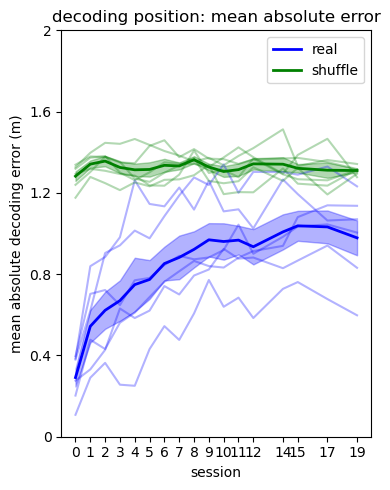

In [14]:

mae_array = np.array([[results[a]['scores_new_list'][day]['mae'] for a in range(len(results))] 
                      for day in range(len(results[0]['scores_new_list']))])
mae_ref= np.array([results[a]['scores_test']['mae'] for a in range(len(results))])
mae_array = np.vstack([mae_ref, mae_array]) / 5

mae_array_shuff = np.array([[results_shuff[a]['scores_new_list'][day]['mae'] for a in range(len(results_shuff))]
                            for day in range(len(results_shuff[0]['scores_new_list']))])
mae_ref_shuff= np.array([results_shuff[a]['scores_test']['mae'] for a in range(len(results_shuff))])
mae_array_shuff = np.vstack([mae_ref_shuff, mae_array_shuff]) / 5

animal_ids = st.animal_labels([res['datapath'] for res in results])
day_cols = st.day_labels(['0'] + maps)

fig, ax = plt.subplots(1, 1, figsize=(4, 5))
plots.plot_average_geometry([mae_array.T, mae_array_shuff.T], ['0']+maps, colors=['b', 'g'], title='decoding position: mean absolute error', ax=ax, ylim=[0, 2], ylabel='mean absolute decoding error (m)', labels= ['real', 'shuffle'])
ax.set_yticks([0, 0.4, 0.8, 1.2, 1.6, 2])
ax.set_yticklabels(['0', '0.4', '0.8', '1.2', '1.6', '2'])
stat1 = st.repeated_measures_anova_general(
    [mae_array.T, mae_array_shuff.T],
    row_labels=animal_ids, col_labels=day_cols,
    condition_labels=['real', 'shuffle'],
    title='Decoding position (MAE, m), decoder trained on d0: real vs shuffle')
display(stat1[0])
display(stat1[1])




In [15]:
all_before_correlations = []
maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
for datapath in datapaths:

    
    hist_sorts = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference='0', maps = maps, transients = False, hist='hist')
    manifold_reference = hist_sorts[0] 
    manifold_before_rotation = [hist_sorts[day] for day in range(1,len(hist_sorts))]
    before_correlation = [pop.ManifoldAnalysis.population_correlation(manifold_before_rotation[day], manifold_reference) for day in range(len(manifold_before_rotation))]    
    
    w1,w2 =analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context1', maps=['0'])
    within_session_correlation = pop.ManifoldAnalysis.population_correlation(w1[0], w2[0])
    
    before_correlation= [within_session_correlation] + before_correlation
    all_before_correlations.append(before_correlation)



all_before_correlations = np.vstack(all_before_correlations)

day,d0 (within session),d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.5371,0.4368,0.4091,0.3407,0.3476,0.3045,0.2873,0.2443,0.2588,0.2597,0.2472,0.2089,0.2117,0.2036,0.2036,0.2022,0.1583
51004,0.7515,0.4970,0.3616,0.3081,0.2817,0.2163,0.2270,0.1807,0.0856,0.0733,0.0628,0.1020,0.0942,0.0915,0.0948,0.0332,0.0859
51007,0.7497,0.5079,0.4503,0.3007,0.2681,0.3054,0.2140,0.3087,0.2058,0.2172,0.1955,0.2404,0.1911,0.2217,0.2196,0.2240,0.1974
63,0.6854,0.3003,0.3285,0.2429,0.2083,0.1876,0.1878,0.1750,0.1791,0.1965,0.1858,0.1804,0.1772,0.1450,0.1354,0.1693,0.1679
64,0.8852,0.6280,0.5408,0.5092,0.4698,0.4063,0.4116,0.3669,0.3299,0.2690,0.3356,0.3191,0.3105,0.2844,0.3004,0.3158,0.3079
65,0.7051,0.5370,0.4634,0.3678,0.3451,0.2958,0.2956,0.2580,0.2299,0.1858,0.1746,0.1790,0.1845,0.1703,0.1709,0.1552,0.1317


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,1.976429,16,0.123527,60.322068,8.300126e-38,0.769105,0.144635
1,Error,0.163823,80,0.002048,NaN,NaN,NaN,NaN


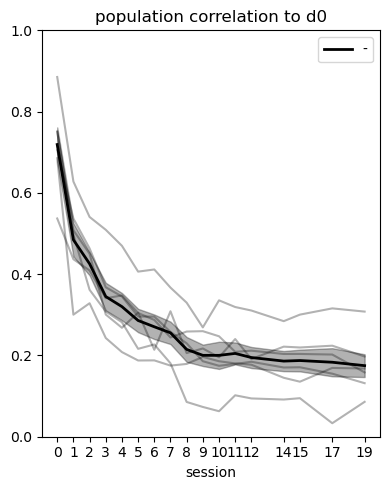

In [16]:

day_cols = ['d0 (within session)'] + st.day_labels(maps)

fig, ax = plt.subplots(figsize=(4, 5))
plots.plot_average_geometry([all_before_correlations], ['0']+maps, colors=['k'], ax=ax, title='population correlation to d0', ylim=[0, 1], labels=['-'])
st.repeated_measures_anova_single_condition(
    all_before_correlations,
    row_labels=animal_ids, col_labels=day_cols,
    condition_label='population correlation to d0',
    title='Population vector correlation to d0 (unaligned)')# included day 0 as